# Regressão Softmax com dados do MNIST utilizando gradiente descendente estocástico por minibatches

O objetivo deste notebook é ilustrar
- o uso do gradiente estocástico por mini-batchs
- utilizando as classes Dataset e DataLoater.

A apresentação da perda nos gráficos é um pouco diferente da usual, mostrando a perda de cada um dos vários minibatches dentro de cada época, de forma que as épocas são apresentadas com valores fracionários.

## Importação das bibliotecas

In [24]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.autograd import Variable
from torch.utils.data import DataLoader

import torchvision
from torchvision.datasets import MNIST

## Dataset e dataloader

### Definição do tamanho do minibatch

In [25]:
batch_size = 100

### Carregamento, criação dataset e do dataloader

In [26]:
dataset_dir = 'MNIST/'

# Load the full MNIST training dataset
full_train_dataset = MNIST(dataset_dir, train=True, download=True,
                      transform=torchvision.transforms.ToTensor())

# Define the split ratio (e.g., 80% for training, 20% for validation)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

# Split the dataset
dataset_train, dataset_val = torch.utils.data.random_split(full_train_dataset, [train_size, val_size])

# Create DataLoaders for training and validation
loader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
loader_val = DataLoader(dataset_val, batch_size=batch_size, shuffle=False) # No need to shuffle validation data

print(f'Número total de amostras de treinamento original: {len(full_train_dataset)}')
print(f'Número de amostras de treinamento: {len(dataset_train)}')
print(f'Número de amostras de validação: {len(dataset_val)}')
print('Número de minibatches de treinamento:', len(loader_train))
print('Número de minibatches de validação:', len(loader_val))

x_train_sample, y_train_sample = next(iter(loader_train))
print("\nDimensões dos dados de um minibatch de treinamento:", x_train_sample.size())
print("Valores mínimo e máximo dos pixels: ", torch.min(x_train_sample), torch.max(x_train_sample))
print("Tipo dos dados das imagens:         ", type(x_train_sample))
print("Tipo das classes das imagens:       ", type(y_train_sample))

Número total de amostras de treinamento original: 60000
Número de amostras de treinamento: 48000
Número de amostras de validação: 12000
Número de minibatches de treinamento: 480
Número de minibatches de validação: 120

Dimensões dos dados de um minibatch de treinamento: torch.Size([100, 1, 28, 28])
Valores mínimo e máximo dos pixels:  tensor(0.) tensor(1.)
Tipo dos dados das imagens:          <class 'torch.Tensor'>
Tipo das classes das imagens:        <class 'torch.Tensor'>


### Usando todas as amostras do MNIST

Neste exemplo utilizaremos todas as amostras de treinamento.

In [27]:
# The original `total_samples` was for the full training set. Now we have a split.
n_batches_train = len(loader_train)
n_batches_val = len(loader_val)
total_train_samples = len(dataset_train)
total_val_samples = len(dataset_val)

print(f'Número de minibatches de treinamento: {n_batches_train}')
print(f'Número de minibatches de validação: {n_batches_val}')
print(f'Total de amostras de treinamento: {total_train_samples}')
print(f'Total de amostras de validação: {total_val_samples}')

Número de minibatches de treinamento: 480
Número de minibatches de validação: 120
Total de amostras de treinamento: 48000
Total de amostras de validação: 12000


## Modelo

In [28]:
model = torch.nn.Linear(28*28, 10)

In [29]:
x = torch.ones(28*28).reshape(1, 784)
print(x.shape)
predict = model(x)
predict

torch.Size([1, 784])


tensor([[ 0.0973, -0.3949,  0.5298,  0.9494, -0.6205,  0.8772, -0.1860,  0.2216,
          0.1063, -1.2554]], grad_fn=<AddmmBackward0>)

## Treinamento

Durante o treinamento, acompanharemos a perda e a acurácia para os conjuntos de treinamento e validação em cada época.

### Inicialização dos parâmetros

In [30]:
n_epochs = 5
learningRate = 0.5

# Utilizaremos CrossEntropyLoss como função de perda
criterion = torch.nn.CrossEntropyLoss()

# Gradiente descendente
optimizer = torch.optim.SGD(model.parameters(), lr=learningRate)

### Laço de treinamento dos parâmetros

In [ ]:
train_losses_per_epoch = []
val_losses_per_epoch = []
train_accuracies_per_epoch = []
val_accuracies_per_epoch = []

for epoch in range(n_epochs):
    # Training phase
    model.train() # Set model to training mode
    correct_train = 0
    total_train = 0
    running_train_loss = 0.0

    for i, (x_train, y_train) in enumerate(loader_train):
        inputs = Variable(x_train.view(-1, 28 * 28))
        labels = Variable(y_train)

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    avg_train_loss = running_train_loss / len(loader_train)
    train_accuracy = correct_train / total_train
    train_losses_per_epoch.append(avg_train_loss)
    train_accuracies_per_epoch.append(train_accuracy)

    # Validation phase
    model.eval() # Set model to evaluation mode
    correct_val = 0
    total_val = 0
    running_val_loss = 0.0

    with torch.no_grad(): # Disable gradient calculations during validation
        for x_val, y_val in loader_val:
            inputs_val = Variable(x_val.view(-1, 28 * 28))
            labels_val = Variable(y_val)

            outputs_val = model(inputs_val)
            loss_val = criterion(outputs_val, labels_val)

            running_val_loss += loss_val.item()
            _, predicted_val = torch.max(outputs_val.data, 1)
            total_val += labels_val.size(0)
            correct_val += (predicted_val == labels_val).sum().item()

    avg_val_loss = running_val_loss / len(loader_val)
    val_accuracy = correct_val / total_val
    val_losses_per_epoch.append(avg_val_loss)
    val_accuracies_per_epoch.append(val_accuracy)

    print(f'Epoch [{epoch+1}/{n_epochs}], ' \
          f'Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.4f}, ' \
          f'Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.4f}')

Epoch [1/5], Train Loss: 0.4096, Train Acc: 0.8834, Val Loss: 0.3215, Val Acc: 0.9094
Epoch [2/5], Train Loss: 0.3127, Train Acc: 0.9124, Val Loss: 0.2976, Val Acc: 0.9162


In [ ]:
print('--- Treinamento Finalizado ---')
print(f'Última perda de treinamento: {train_losses_per_epoch[-1]:.4f}')
print(f'Última acurácia de treinamento: {train_accuracies_per_epoch[-1]:.4f}')
print(f'Última perda de validação: {val_losses_per_epoch[-1]:.4f}')
print(f'Última acurácia de validação: {val_accuracies_per_epoch[-1]:.4f}')

### Visualizando a evolução da perda e acurácia

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, n_epochs + 1), train_losses_per_epoch, label='Perda de Treinamento')
plt.plot(range(1, n_epochs + 1), val_losses_per_epoch, label='Perda de Validação')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.title('Evolução da Perda (Treinamento vs. Validação)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, n_epochs + 1), train_accuracies_per_epoch, label='Acurácia de Treinamento')
plt.plot(range(1, n_epochs + 1), val_accuracies_per_epoch, label='Acurácia de Validação')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.title('Evolução da Acurácia (Treinamento vs. Validação)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Observações sobre os gráficos

Estes gráficos mostram a perda e a acurácia calculadas ao final de cada época para os conjuntos de treinamento e validação. Idealmente, a perda de treinamento e validação deve diminuir, e a acurácia deve aumentar, com as curvas de validação seguindo de perto as de treinamento. Divergências significativas podem indicar overfitting ou underfitting.

# Atividades

## Perguntas

1. Qual é o tamanho do mini-batch?
Resposta: cada mini-batch possue 100 amostras.
2. Em uma época, quantos mini-batches existem?
Resposta: 48.000 / 100 = 480 mini-batches por época
3. Qual é a definição de época?
Resposta: Uma época é uma passagem em todo o treinamento

## Exercícios


1. Coloque um print no final de cada minibatch, no mesmo estilo do print do final de época, no seguinte estilo:
    - Época: 1/4, batch: 600


In [ ]:
for i, (x_train, y_train) in enumerate(loader_train):
        inputs = Variable(x_train.view(-1, 28 * 28))
        labels = Variable(y_train)

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

        # Print no final de cada mini-batch
        print('Época: {}/{}, batch: {}'.format(epoch+1, n_epochs, i+1))

2. Altere o tamanho de minibatch (batch_size) algumas vezes, refaça o treinamento, e compare no gráfico abaixo a queda da perda para cada tamanho de minibatch.

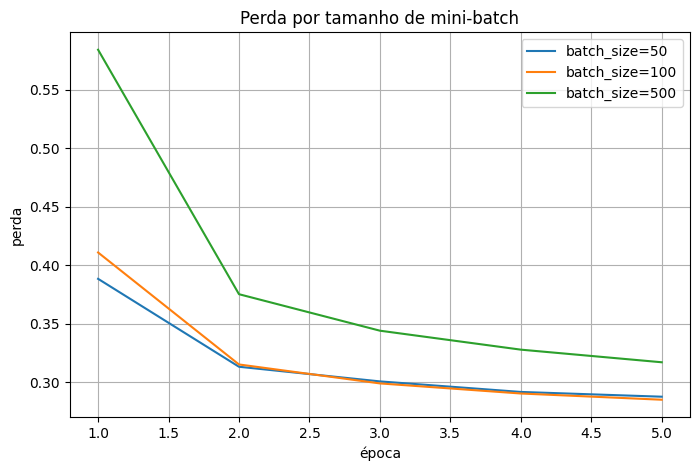

In [23]:
batch_sizes = [50, 100, 500]
results = {}

for bs in batch_sizes:
    model_bs = torch.nn.Linear(28*28, 10)
    optimizer_bs = torch.optim.SGD(model_bs.parameters(), lr=0.5)
    loader_bs = DataLoader(dataset_train, batch_size=bs, shuffle=True)

    losses_bs = []
    for epoch in range(n_epochs):
        model_bs.train()
        running_loss = 0.0
        for x_b, y_b in loader_bs:
            inputs = x_b.view(-1, 28*28)
            outputs = model_bs(inputs)
            loss = criterion(outputs, y_b)
            optimizer_bs.zero_grad()
            loss.backward()
            optimizer_bs.step()
            running_loss += loss.item()
        losses_bs.append(running_loss / len(loader_bs))

    results[bs] = losses_bs

plt.figure(figsize=(8, 5))
for bs, losses in results.items():
    plt.plot(range(1, n_epochs+1), losses, label=f'batch_size={bs}')
plt.xlabel('época')
plt.ylabel('perda')
plt.title('Perda por tamanho de mini-batch')
plt.legend()
plt.grid(True)
plt.show()

## Conclusões sobre os experimentos deste notebook


A escolha do tamanho dos mini-batches equilibra velocidade e estabilidade: lotes menores oferecem convergência rápida em menos épocas por meio de atualizações ruidosas, mas tornam o treino por época mais demorado, enquanto lotes maiores suavizam os gradientes e otimizam a memória à custa de uma convergência mais lenta. Complementando a eficiência do fluxo, as boas práticas exigem alternar o modelo entre model.train() e model.eval() para ajustar o comportamento de camadas dinâmicas como Dropout e BatchNorm, além de aplicar torch.no_grad() na validação para desativar os gradientes, economizar recursos computacionais e acelerar a inferência.